# Gravity Data Processing
# Base station and instrument drift corrections
## Where: Howelson Hill Onyx Mine, Steamboat Springs, CO
### Molly Bilhartz, Samamtha Lopez, Tessa Murphy

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PY_FOLDER = PROJECT_ROOT / "PY files"

if str(PY_FOLDER) not in sys.path:
    sys.path.insert(0, str(PY_FOLDER))

In [4]:
from gravity_data import *

In [5]:
from gravity_data import process_gravity_through_drift

cg5_1_path = "../../data/gravity/raw_data/Raw_Data_2026_05_27_gravity/CG5_1/T162208.TXT"
cg5_2_path = "../../data/gravity/raw_data/Raw_Data_2026_05_27_gravity/CG5_2/T162142.TXT"

raw, labeled_raw, profile_raw, base_raw, profile_avg, base_summary, drift_corrected = process_gravity_through_drift(
    cg5_1_path,
    cg5_2_path
)

base_summary

,instrument,reading_type,base_gravity_mean_mgal,base_gravity_std_mgal,base_sd_mean_mgal,n_base_readings,mean_decimal_time,first_time,last_time
0,CG5-1,final_base,3705.155667,0.000577,0.040333,3,46138.604053,2026-05-27 14:30:37,2026-05-27 14:31:49
1,CG5-1,initial_base,3705.058333,0.001155,0.036667,3,46138.515873,2026-05-27 12:23:26,2026-05-27 12:24:38
2,CG5-2,final_base,3891.865667,0.001528,0.037667,3,46138.612937,2026-05-27 14:43:26,2026-05-27 14:44:38
3,CG5-2,initial_base,3891.738000,0.001732,0.080333,3,46138.515813,2026-05-27 12:23:21,2026-05-27 12:24:33


In [6]:
drift_corrected

,instrument,station,gravity_mean_mgal,gravity_std_mgal,sd_mean_mgal,sd_min_mgal,sd_max_mgal,n_readings,first_time,last_time,...,alt_mean,tiltx_mean,tilty_mean,temp_mean,initial_base_mgal,final_base_mgal,total_drift_mgal,drift_rate_mgal_per_day,drift_correction_mgal,gravity_drift_corrected_mgal
0,CG5-1,15.000000,3705.297000,0.001000,0.056000,0.049,0.070,3,2026-05-27 12:33:21,2026-05-27 12:34:33,...,0.000000,-11.533333,-12.433333,-0.980000,3705.058333,3705.155667,0.097333,1.103803,0.007583,3705.289417
1,CG5-1,15.500000,3705.389667,0.004041,0.029667,0.029,0.031,3,2026-05-27 14:11:05,2026-05-27 14:12:17,...,0.000000,37.600000,-23.566667,-1.110000,3705.058333,3705.155667,0.097333,1.103803,0.082380,3705.307286
2,CG5-1,16.000000,3705.321000,0.001000,0.058600,0.017,0.180,5,2026-05-27 12:37:53,2026-05-27 12:41:38,...,0.000000,1.160000,-4.880000,-0.966000,3705.058333,3705.155667,0.097333,1.103803,0.012136,3705.308864
3,CG5-1,16.500000,3705.415000,0.003606,0.029667,0.027,0.033,3,2026-05-27 14:06:10,2026-05-27 14:07:22,...,0.000000,20.733333,8.433333,-1.113333,3705.058333,3705.155667,0.097333,1.103803,0.078620,3705.336380
4,CG5-1,17.000000,3705.359333,0.002517,0.049333,0.034,0.071,3,2026-05-27 12:46:07,2026-05-27 12:47:19,...,0.000000,-11.566667,-3.000000,-1.003333,3705.058333,3705.155667,0.097333,1.103803,0.017355,3705.341978
5,CG5-1,17.500000,3705.427000,0.002000,0.047600,0.025,0.101,5,2026-05-27 14:00:18,2026-05-27 14:03:36,...,0.000000,-1.220000,3.960000,-1.100000,3705.058333,3705.155667,0.097333,1.103803,0.075004,3705.351996
6,CG5-1,18.000000,3705.403667,0.002517,0.023333,0.020,0.029,3,2026-05-27 12:52:40,2026-05-27 12:53:52,...,0.000000,-4.200000,6.066667,-1.036667,3705.058333,3705.155667,0.097333,1.103803,0.022370,3705.381296
7,CG5-1,19.000000,3705.434667,0.002517,0.024667,0.017,0.035,3,2026-05-27 12:57:58,2026-05-27 12:59:10,...,0.000000,-11.566667,-8.133333,-1.060000,3705.058333,3705.155667,0.097333,1.103803,0.026425,3705.408242
8,CG5-1,20.000000,3705.431333,0.000577,0.032667,0.027,0.037,3,2026-05-27 13:03:09,2026-05-27 13:04:21,...,0.000000,-6.633333,-6.400000,-1.060000,3705.058333,3705.155667,0.097333,1.103803,0.030391,3705.400942
9,CG5-1,21.000000,3705.462333,0.000577,0.025333,0.018,0.036,3,2026-05-27 13:07:54,2026-05-27 13:09:06,...,0.000000,-19.333333,-4.333333,-1.036667,3705.058333,3705.155667,0.097333,1.103803,0.034030,3705.428303


In [7]:
profile_raw[
    (profile_raw["instrument"] == "CG5-1") &
    (profile_raw["station"].isin([15, 16]))
][["instrument", "station", "gravity_mgal", "sd_mgal", "time", "datetime", "reading_type"]]

,instrument,station,gravity_mgal,sd_mgal,time,datetime,reading_type
3,CG5-1,15.0,3705.296,0.049,12:33:21,2026-05-27 12:33:21,profile
4,CG5-1,15.0,3705.297,0.049,12:33:59,2026-05-27 12:33:59,profile
5,CG5-1,15.0,3705.298,0.070,12:34:33,2026-05-27 12:34:33,profile
6,CG5-1,16.0,3705.320,0.043,12:37:53,2026-05-27 12:37:53,profile
7,CG5-1,16.0,3705.321,0.180,12:38:31,2026-05-27 12:38:31,profile
8,CG5-1,16.0,3705.320,0.017,12:40:26,2026-05-27 12:40:26,profile
9,CG5-1,16.0,3705.322,0.026,12:41:04,2026-05-27 12:41:04,profile
10,CG5-1,16.0,3705.322,0.027,12:41:38,2026-05-27 12:41:38,profile


In [8]:
from gravity_data import process_gravity_full

raw, labeled_raw, profile_raw, base_raw, profile_avg, base_summary, drift_corrected, combined_profile = process_gravity_full(
    cg5_1_path,
    cg5_2_path
)

combined_profile

,instrument,station,gravity_mean_mgal,gravity_drift_corrected_mgal,relative_gravity_mgal,gravity_std_mgal,sd_mean_mgal,n_readings,first_time,last_time,drift_correction_mgal,initial_base_mgal,final_base_mgal,total_drift_mgal
0,CG5-2,1.000000,3891.825833,3891.815442,0.077442,0.008305,0.064667,6,2026-05-27 12:32:20,2026-05-27 12:38:22,0.010391,3891.738000,3891.865667,0.127667
1,CG5-2,2.000000,3891.865500,3891.740971,0.002971,0.002121,0.082000,2,2026-05-27 14:40:17,2026-05-27 14:40:55,0.124529,3891.738000,3891.865667,0.127667
2,CG5-2,3.000000,3891.842667,3891.826144,0.088144,0.002309,0.095333,3,2026-05-27 12:41:29,2026-05-27 12:42:41,0.016523,3891.738000,3891.865667,0.127667
3,CG5-2,4.000000,3891.865000,3891.837418,0.099418,0.002000,0.057667,3,2026-05-27 12:53:37,2026-05-27 12:54:49,0.027582,3891.738000,3891.865667,0.127667
4,CG5-2,5.000000,3891.885333,3891.852813,0.114813,0.006506,0.026000,3,2026-05-27 12:59:02,2026-05-27 13:00:14,0.032520,3891.738000,3891.865667,0.127667
5,CG5-2,6.000000,3891.899333,3891.861603,0.123603,0.003055,0.045000,3,2026-05-27 13:04:45,2026-05-27 13:05:57,0.037730,3891.738000,3891.865667,0.127667
6,CG5-2,7.000000,3891.914000,3891.871332,0.133332,0.002646,0.053333,3,2026-05-27 13:10:10,2026-05-27 13:11:22,0.042668,3891.738000,3891.865667,0.127667
7,CG5-2,8.000000,3891.935667,3891.887197,0.149197,0.002517,0.064667,3,2026-05-27 13:16:32,2026-05-27 13:17:44,0.048469,3891.738000,3891.865667,0.127667
8,CG5-2,9.000000,3891.955333,3891.901348,0.163348,0.001528,0.050000,3,2026-05-27 13:22:35,2026-05-27 13:23:47,0.053986,3891.738000,3891.865667,0.127667
9,CG5-2,10.000000,3891.974333,3891.914853,0.176853,0.000577,0.043667,3,2026-05-27 13:28:37,2026-05-27 13:29:49,0.059480,3891.738000,3891.865667,0.127667


In [9]:
from gravity_data import apply_instrument_tie_correction

tied_profile = apply_instrument_tie_correction(
    combined_profile,
    reference_instrument="CG5-2",
    tie_station=15.0
)

tied_profile[
    ["instrument", "station", "relative_gravity_mgal", "instrument_tie_offset_mgal", "gravity_tied_mgal"]
]

,instrument,station,relative_gravity_mgal,instrument_tie_offset_mgal,gravity_tied_mgal
0,CG5-2,1.000000,0.077442,0.000000,0.077442
1,CG5-2,2.000000,0.002971,0.000000,0.002971
2,CG5-2,3.000000,0.088144,0.000000,0.088144
3,CG5-2,4.000000,0.099418,0.000000,0.099418
4,CG5-2,5.000000,0.114813,0.000000,0.114813
5,CG5-2,6.000000,0.123603,0.000000,0.123603
6,CG5-2,7.000000,0.133332,0.000000,0.133332
7,CG5-2,8.000000,0.149197,0.000000,0.149197
8,CG5-2,9.000000,0.163348,0.000000,0.163348
9,CG5-2,10.000000,0.176853,0.000000,0.176853


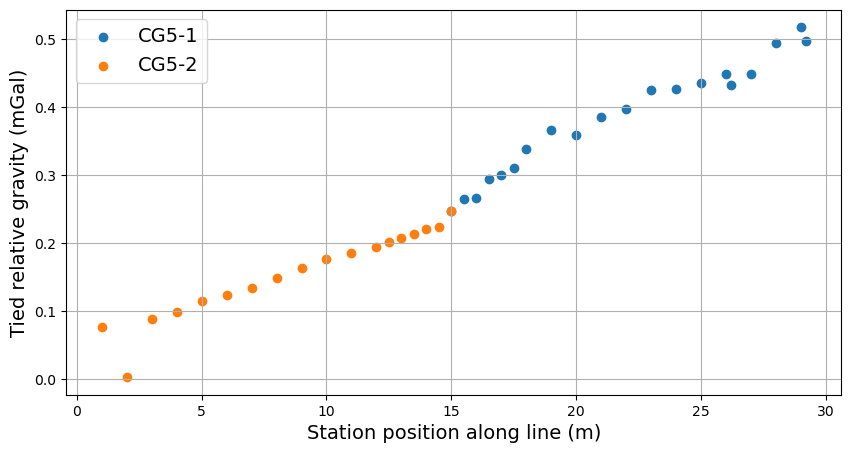

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for inst, group in tied_profile.groupby("instrument"):
    plt.scatter(group["station"], group["gravity_tied_mgal"], label=inst)

plt.xlabel("Station position along line (m)", fontsize=14)
plt.ylabel("Tied relative gravity (mGal)", fontsize=14)
#plt.title("Instrument-Tied Gravity Profile")
plt.grid(True)
plt.legend(fontsize=14)

plt.savefig(
    "../../figures/Final_figures/Grav_Instrument_Tie_Correction.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Incorperating GPS elevation for Free-Air and Buogeur corrections

In [11]:
from gravity_data import (
    process_gravity_full,
    apply_instrument_tie_correction,
    merge_gravity_with_gps,
    apply_free_air_and_bouguer
)

cg5_1_path = "../../data/gravity/raw_data/Raw_Data_2026_05_27_gravity/CG5_1/T162208.TXT"
cg5_2_path = "../../data/gravity/raw_data/Raw_Data_2026_05_27_gravity/CG5_2/T162142.TXT"
gps_path = "../../data/gravity/raw_data/gps_data/gps_points_with_elevation.csv"

raw, labeled_raw, profile_raw, base_raw, profile_avg, base_summary, drift_corrected, combined_profile = process_gravity_full(
    cg5_1_path,
    cg5_2_path
)

tied_profile = apply_instrument_tie_correction(
    combined_profile,
    reference_instrument="CG5-2",
    tie_station=15.0
)

gravity_gps, gps_elev = merge_gravity_with_gps(
    tied_profile,
    gps_path
)

bouguer_corrected = apply_free_air_and_bouguer(
    gravity_gps,
    gravity_col="gravity_tied_mgal",
    elevation_col="elevation_m",
    density_kg_m3=2670
)

bouguer_corrected[
    [
        "instrument",
        "station",
        "gravity_tied_mgal",
        "elevation_m",
        "height_above_reference_m",
        "free_air_correction_mgal",
        "bouguer_correction_mgal",
        "free_air_gravity_mgal",
        "bouguer_gravity_mgal",
    ]
]

[16.5, 17.5, 26.2000008, 29.2000008]


,instrument,station,gravity_tied_mgal,elevation_m,height_above_reference_m,free_air_correction_mgal,bouguer_correction_mgal,free_air_gravity_mgal,bouguer_gravity_mgal
0,CG5-2,1.000000,0.077442,2112.468,2.603,0.803286,0.291414,0.880728,0.589314
1,CG5-2,2.000000,0.002971,2112.006,2.141,0.660713,0.239692,0.663683,0.423992
2,CG5-2,3.000000,0.088144,2111.569,1.704,0.525854,0.190768,0.613998,0.423230
3,CG5-2,4.000000,0.099418,2111.692,1.827,0.563812,0.204538,0.663230,0.458692
4,CG5-2,5.000000,0.114813,2111.862,1.997,0.616274,0.223570,0.731087,0.507517
5,CG5-2,6.000000,0.123603,2111.790,1.925,0.594055,0.215510,0.717658,0.502149
6,CG5-2,7.000000,0.133332,2111.286,1.421,0.438521,0.159085,0.571853,0.412767
7,CG5-2,8.000000,0.149197,2111.152,1.287,0.397168,0.144084,0.546366,0.402282
8,CG5-2,9.000000,0.163348,2111.213,1.348,0.415993,0.150913,0.579340,0.428428
9,CG5-2,10.000000,0.176853,2111.151,1.286,0.396860,0.143972,0.573713,0.429741


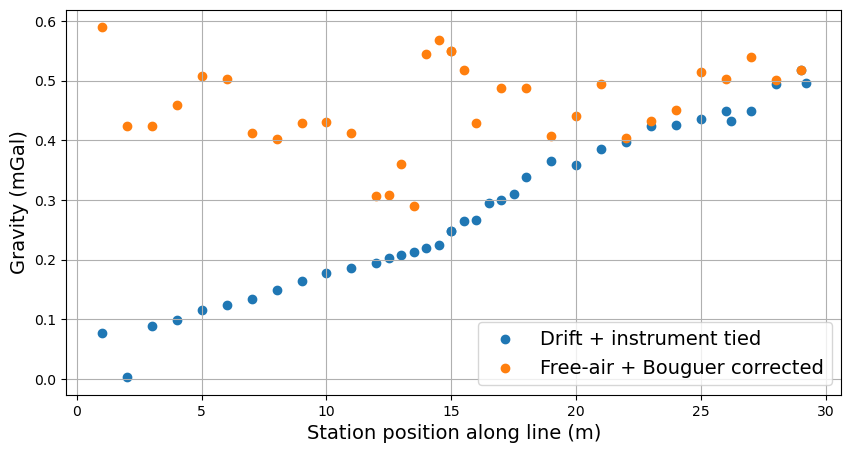

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    bouguer_corrected["station"],
    bouguer_corrected["gravity_tied_mgal"],
    label="Drift + instrument tied"
)

plt.scatter(
    bouguer_corrected["station"],
    bouguer_corrected["bouguer_gravity_mgal"],
    label="Free-air + Bouguer corrected"
)

plt.xlabel("Station position along line (m)", fontsize=14)
plt.ylabel("Gravity (mGal)", fontsize=14)
#plt.title("Gravity Before and After Elevation/Mass Corrections")
plt.grid(True)
plt.legend(fontsize=14)
plt.savefig(
    "../../figures/Final_figures/Grav_FreeAir_Bouguer_Correction_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

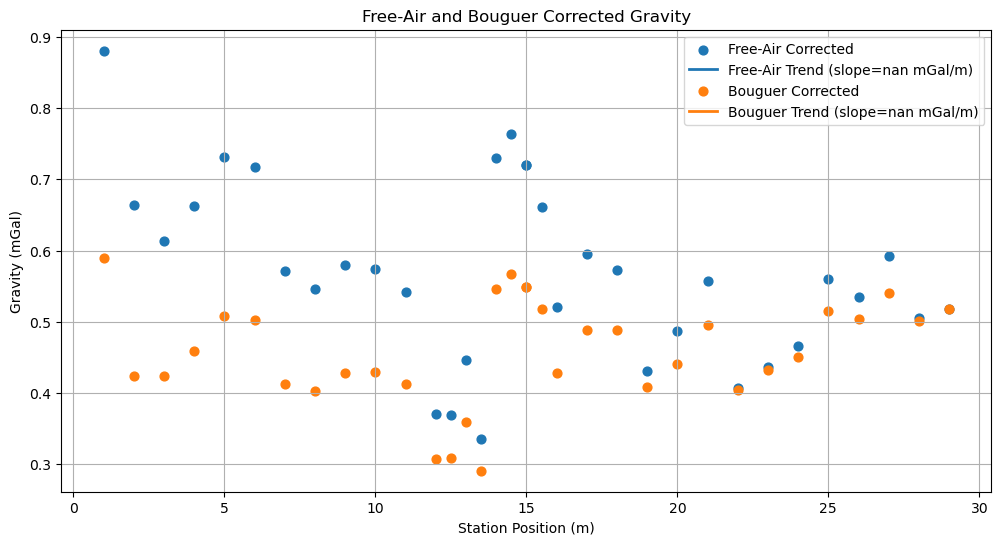

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Sort by station
# -------------------------
df = bouguer_corrected.sort_values("station").copy()

x = df["station"].values

# -------------------------
# Free-air trend
# -------------------------
free_air = df["free_air_gravity_mgal"].values

free_air_coeff = np.polyfit(x, free_air, 1)
free_air_trend = np.polyval(free_air_coeff, x)

# -------------------------
# Bouguer trend
# -------------------------
bouguer = df["bouguer_gravity_mgal"].values

bouguer_coeff = np.polyfit(x, bouguer, 1)
bouguer_trend = np.polyval(bouguer_coeff, x)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(12,6))

plt.scatter(
    x,
    free_air,
    s=40,
    label="Free-Air Corrected"
)

plt.plot(
    x,
    free_air_trend,
    linewidth=2,
    label=f"Free-Air Trend (slope={free_air_coeff[0]:.4f} mGal/m)"
)

plt.scatter(
    x,
    bouguer,
    s=40,
    label="Bouguer Corrected"
)

plt.plot(
    x,
    bouguer_trend,
    linewidth=2,
    label=f"Bouguer Trend (slope={bouguer_coeff[0]:.4f} mGal/m)"
)

plt.xlabel("Station Position (m)")
plt.ylabel("Gravity (mGal)")
plt.title("Free-Air and Bouguer Corrected Gravity")
plt.grid(True)
plt.legend()

plt.show()

In [14]:
bouguer_corrected[
    ["station", "free_air_gravity_mgal", "bouguer_gravity_mgal"]
].isna().sum()

station                  0
free_air_gravity_mgal    4
bouguer_gravity_mgal     4
dtype: int64

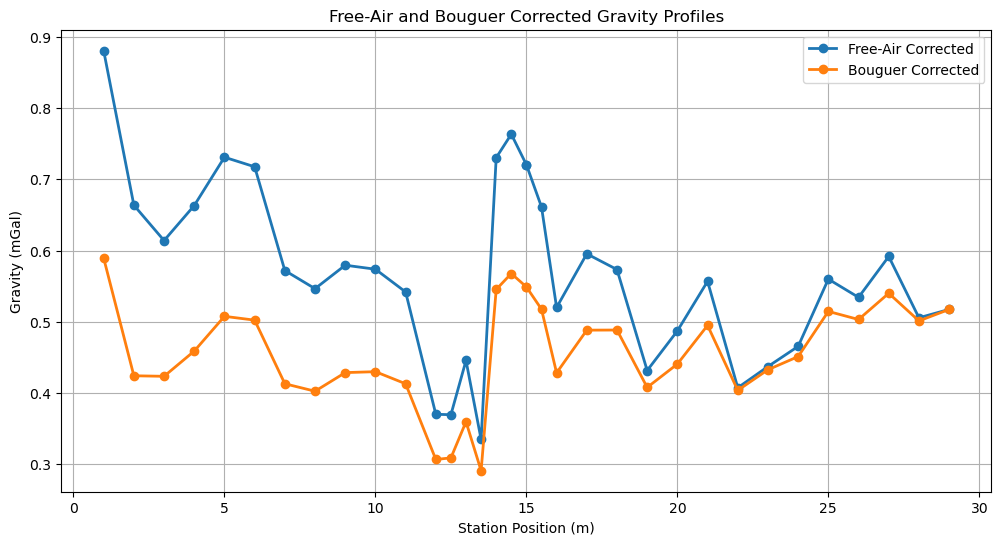

In [15]:
import matplotlib.pyplot as plt

plot_df = (
    bouguer_corrected
    .dropna(subset=["free_air_gravity_mgal", "bouguer_gravity_mgal"])
    .sort_values("station")
)

plt.figure(figsize=(12,6))

plt.plot(
    plot_df["station"],
    plot_df["free_air_gravity_mgal"],
    marker="o",
    linewidth=2,
    label="Free-Air Corrected"
)

plt.plot(
    plot_df["station"],
    plot_df["bouguer_gravity_mgal"],
    marker="o",
    linewidth=2,
    label="Bouguer Corrected"
)

plt.xlabel("Station Position (m)")
plt.ylabel("Gravity (mGal)")
plt.title("Free-Air and Bouguer Corrected Gravity Profiles")
plt.grid(True)
plt.legend()

plt.show()

## FInal dataset and Final plot

In [26]:
# Interpolate missing elevation data points
bouguer_corrected[
    bouguer_corrected["elevation_m"].isna()
][["station","instrument"]]

gravity_gps_interp = gravity_gps.copy()

gravity_gps_interp = gravity_gps_interp.sort_values("station")

gravity_gps_interp["elevation_m"] = (
    gravity_gps_interp["elevation_m"]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

gravity_gps_interp["elevation_m"].isna().sum()

0

In [28]:
# Interpolate missing elevation data points
gravity_gps_interp = gravity_gps.copy()
gravity_gps_interp = gravity_gps_interp.sort_values("station")

gravity_gps_interp["elevation_m"] = (
    gravity_gps_interp["elevation_m"]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

# Re-run free-air and Bouguer corrections using interpolated elevations
bouguer_corrected_interp = apply_free_air_and_bouguer(
    gravity_gps_interp,
    gravity_col="gravity_tied_mgal",
    elevation_col="elevation_m",
    density_kg_m3=2670
)

# Create final dataset from interpolated corrected data
final_gravity = (
    bouguer_corrected_interp
    .copy()
    .sort_values("station")
)

final_gravity["gravity_final_mgal"] = final_gravity["bouguer_gravity_mgal"]

final_gravity = final_gravity[
    [
        "station",
        "gravity_final_mgal",
        "elevation_m",
        "latitude",
        "longitude",
        "free_air_correction_mgal",
        "bouguer_correction_mgal",
        "gravity_tied_mgal",
        "instrument"
    ]
]

final_gravity.head()

,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2


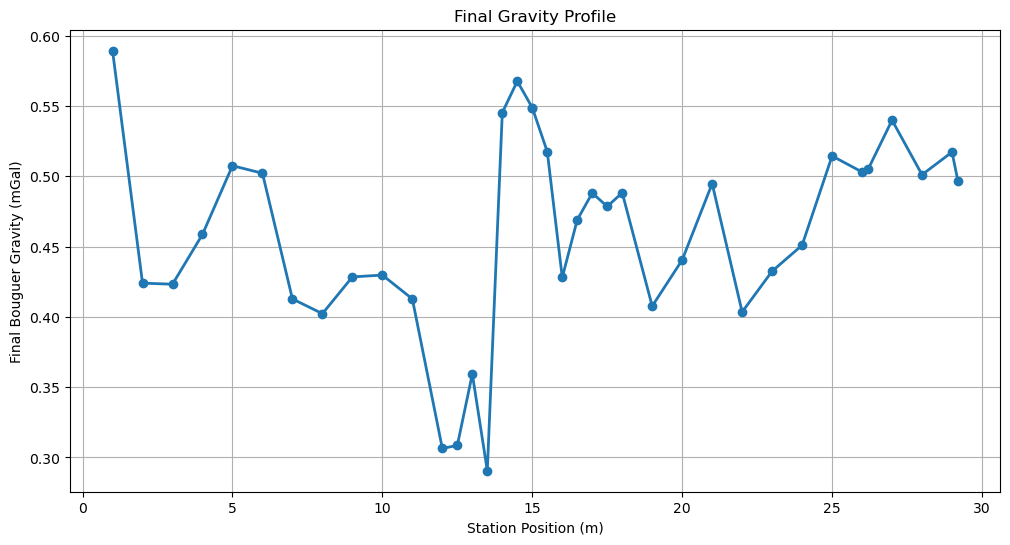

In [30]:
import matplotlib.pyplot as plt

plot_df = (
    final_gravity
    .dropna(subset=["gravity_final_mgal"])
    .sort_values("station")
)

plt.figure(figsize=(12,6))

plt.plot(
    plot_df["station"],
    plot_df["gravity_final_mgal"],
    marker="o",
    linewidth=2
)

plt.xlabel("Station Position (m)")
plt.ylabel("Final Bouguer Gravity (mGal)")
plt.title("Final Gravity Profile")
plt.grid(True)

plt.show()

In [39]:
#final_gravity.to_csv("../../data/gravity/Onyx_Gravity_Final_Bouguer_Corrected.csv", index=False)

## check corrections to see if the bouguer parameters are controlling the negative anomaly

Re-run Bouguer corrections with sandstone densities: 2200, 2300, 2400, 2500 kg/m³.
Plot residuals for each density.
See whether the negative anomaly near 12–14 m persists.
If it persists across density choices, it is probably a real low-density zone.
If it disappears or moves a lot, the correction assumptions are driving the anomaly.

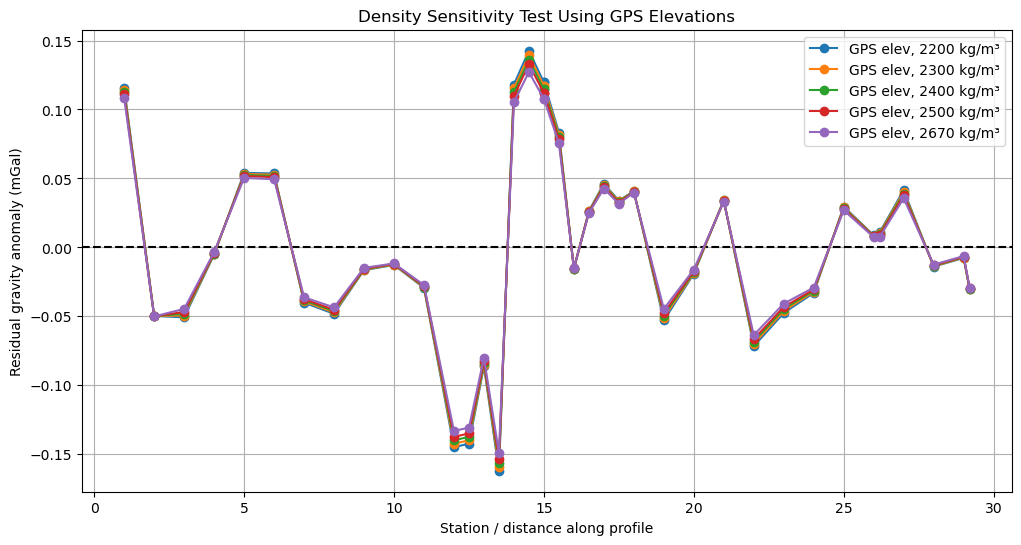

,elevation_source,density_kg_m3,min_residual_mgal,station_of_minimum,residual_std_mgal,residual_range_mgal
0,GPS,2200,-0.161894,13.5,0.071971,0.304486
1,GPS,2300,-0.159154,13.5,0.070604,0.298463
2,GPS,2400,-0.156415,13.5,0.069239,0.292440
3,GPS,2500,-0.153676,13.5,0.067876,0.286417
4,GPS,2670,-0.149019,13.5,0.065564,0.276178


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../../data/gravity/Onyx_Gravity_Final_Bouguer_Corrected.csv")

# Optional GPS file
gps = pd.read_csv("../../data/gravity/raw_data/gps_data/gps_points_with_elevation.csv")

# -----------------------------
# Basic setup
# -----------------------------
df = df.reset_index(drop=True)

# Use station column if it exists, otherwise use row number
if "station" in df.columns:
    x = df["station"].values.astype(float)
else:
    x = np.arange(1, len(df) + 1)

g_base = df["gravity_tied_mgal"].values.astype(float)

# Original elevation from corrected file
elev_original = df["elevation_m"].values.astype(float)

# -----------------------------
# Match GPS elevations
# -----------------------------
gps = gps.reset_index(drop=True)

if "station" in gps.columns and "station" in df.columns:
    gps_use = gps[["station", "elevation_m"]].rename(
        columns={"elevation_m": "gps_elevation_m"}
    )

    df2 = df.merge(gps_use, on="station", how="left")
    elev_gps = df2["gps_elevation_m"].values.astype(float)

else:
    # If GPS file has same order as gravity file
    elev_gps = gps["elevation_m"].values.astype(float)

    if len(elev_gps) != len(df):
        raise ValueError("GPS elevation file length does not match gravity file length.")

# Fill missing GPS elevations
elev_gps = pd.Series(elev_gps).interpolate().bfill().ffill().values

# -----------------------------
# Correction constants
# -----------------------------
FREE_AIR_GRAD = 0.3086      # mGal/m
BOUGUER_COEFF = 0.04193    # mGal/m per g/cm^3

densities = [2200, 2300, 2400, 2500, 2670]
trend_order = 2

# -----------------------------
# Function to recompute residuals
# -----------------------------
def compute_residuals(g_base, elevation, rho_kgm3, x, trend_order=2):
    rho_gcc = rho_kgm3 / 1000

    h_rel = elevation - elevation[0]

    free_air = FREE_AIR_GRAD * h_rel
    bouguer = BOUGUER_COEFF * rho_gcc * h_rel

    g_bouguer = g_base + free_air - bouguer

    trend = np.polyval(np.polyfit(x, g_bouguer, trend_order), x)

    residual = g_bouguer - trend

    return g_bouguer, trend, residual, free_air, bouguer

# -----------------------------
# Run density test with GPS elevations
# -----------------------------
results = []

plt.figure(figsize=(12,6))
plt.axhline(0, color="k", linestyle="--")

for rho in densities:
    g_bouguer, trend, residual, free_air, bouguer = compute_residuals(
        g_base=g_base,
        elevation=elev_gps,
        rho_kgm3=rho,
        x=x,
        trend_order=trend_order
    )

    results.append({
        "elevation_source": "GPS",
        "density_kg_m3": rho,
        "min_residual_mgal": np.min(residual),
        "station_of_minimum": x[np.argmin(residual)],
        "residual_std_mgal": np.std(residual),
        "residual_range_mgal": np.max(residual) - np.min(residual)
    })

    plt.plot(x, residual, "o-", label=f"GPS elev, {rho} kg/m³")

plt.xlabel("Station / distance along profile")
plt.ylabel("Residual gravity anomaly (mGal)")
plt.title("Density Sensitivity Test Using GPS Elevations")
plt.grid(True)
plt.legend()
plt.show()

summary_gps = pd.DataFrame(results)
summary_gps

This plot shows that changing the densities from 2200 to 2670 kg/m^3 didn't change any of the negative residual anomalies, all it did was change residual amplitude slightly. This density sensitivity test shows that the the choice of density for the bouguer correction had no effect on the negative residual anomalies. 